In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel('emissions.xlsx',skiprows=14)

In [3]:
df.head()

,Unnamed: 0,kt,Strom,Wärme,Verkehr,Summe,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,1990,1990.0,21284.154354,7083.901354,0.000000,28368.055708,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1995,1995.0,27543.670986,7182.968207,79.939006,34806.578199,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,2000.0,33929.987117,12550.930224,537.218864,47018.136204,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_clean=df[['Unnamed: 0', 'Strom','Wärme','Verkehr','Summe']].dropna()

In [5]:
print(df.columns)

Index(['Unnamed: 0', 'kt', 'Strom', 'Wärme', 'Verkehr', 'Summe', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20'],
      dtype='object')


In [6]:
df_clean= df_clean.rename(columns={'Unnamed: 0': 'Jahr'})

In [7]:
df_clean.head()

,Jahr,Strom,Wärme,Verkehr,Summe
0,1990,21284.154354,7083.901354,0.000000,28368.055708
2,1995,27543.670986,7182.968207,79.939006,34806.578199
4,2000,33929.987117,12550.930224,537.218864,47018.136204
6,2005,56052.086508,20352.378298,4246.966369,80651.431175
11,2010,74156.81806,32157.526994,6663.069756,112977.414809


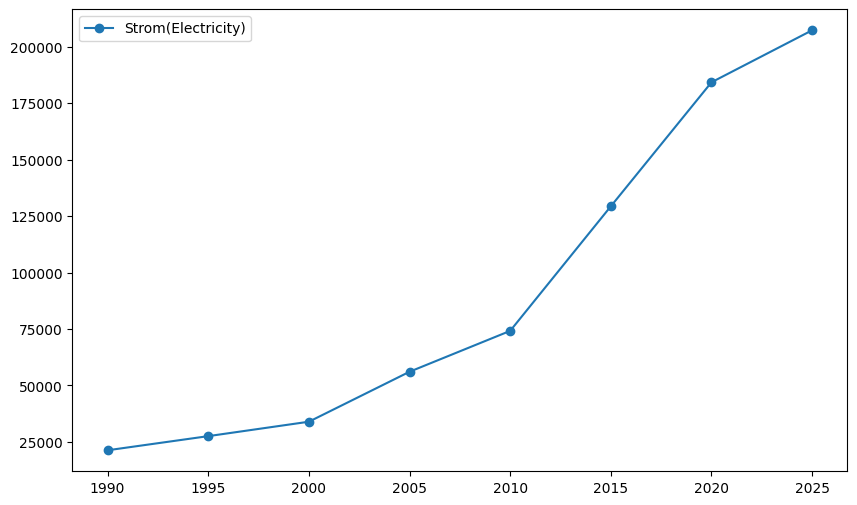

In [8]:
plt.figure(figsize=(10,6))
plt.plot(df_clean['Jahr'], df_clean['Strom'],label= 'Strom(Electricity)', marker='o')
plt.legend()
plt.show()

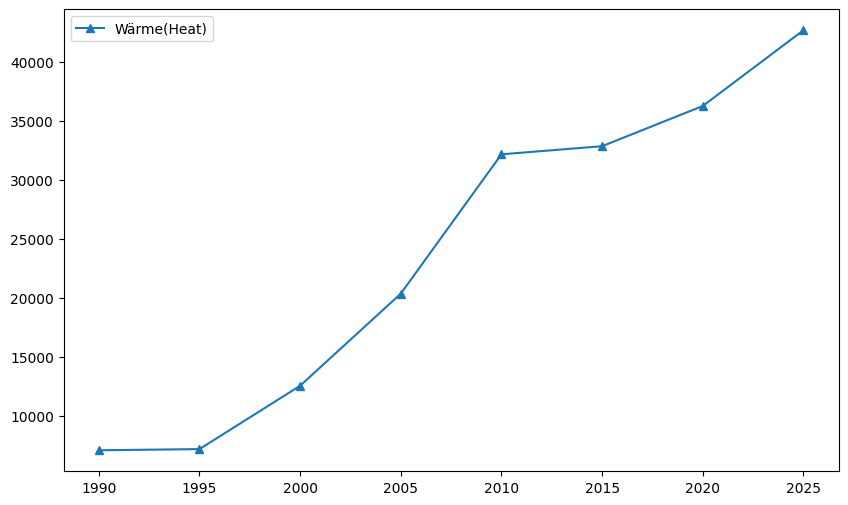

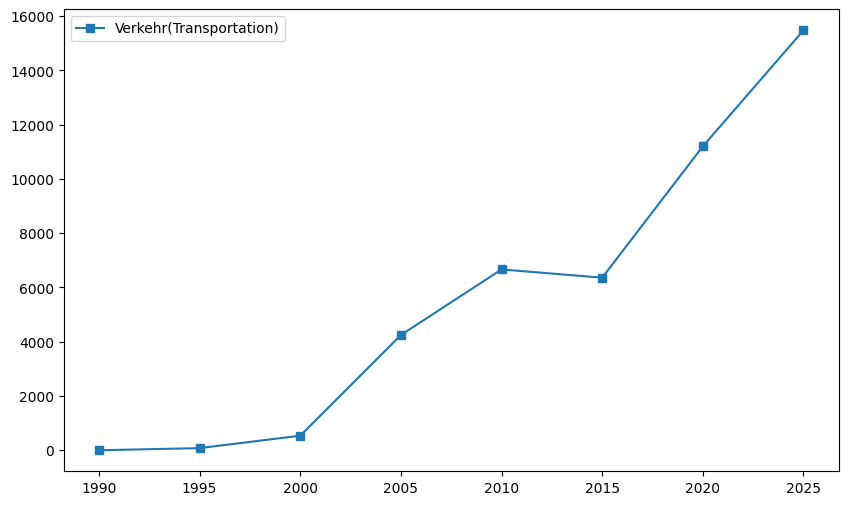

In [9]:
plt.figure(figsize=(10,6))
plt.plot(df_clean['Jahr'], df_clean['Wärme'],label= 'Wärme(Heat)', marker='^')
plt.legend()
plt.show()
plt.figure(figsize=(10,6))
plt.plot(df_clean['Jahr'], df_clean['Verkehr'],label= 'Verkehr(Transportation)', marker='s')
plt.legend()
plt.show()

In [10]:
df_clean['Strom_%']= (df_clean['Strom']/df_clean['Summe'])*100
df_clean['Wärme_%']= (df_clean['Wärme']/df_clean['Summe'])*100
df_clean['Verkehr_%']= (df_clean['Verkehr']/df_clean['Summe'])*100
print(df_clean[['Jahr','Strom_%', 'Wärme_%','Verkehr_%']].head())


    Jahr    Strom_%    Wärme_%  Verkehr_%
0   1990  75.028598  24.971402   0.000000
2   1995  79.133521  20.636812   0.229666
4   2000  72.163616  26.693806   1.142578
6   2005  69.499184  25.234987   5.265829
11  2010  65.638622  28.463677   5.897701


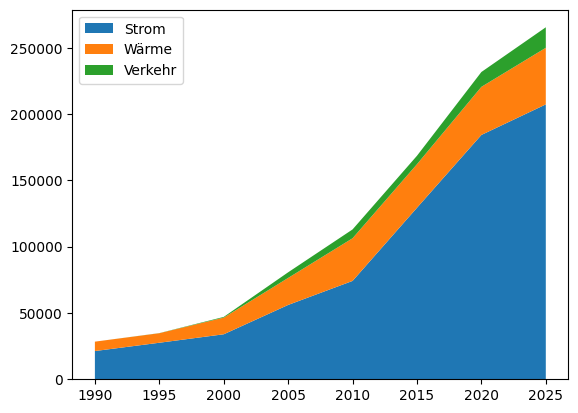

In [14]:
cols = ['Strom', 'Wärme', 'Verkehr']

for col in cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.strip()
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean['Jahr'] = pd.to_numeric(df_clean['Jahr'], errors='coerce')
df_clean = df_clean.dropna(subset=['Jahr'] + cols)

plt.stackplot(
    df_clean['Jahr'],
    df_clean['Strom'],
    df_clean['Wärme'],
    df_clean['Verkehr'],
    labels=['Strom', 'Wärme', 'Verkehr']
)

plt.legend()
plt.show()